# Notebook containing various post processing and verification scripts

### Each section is self contained (all needed functions and imports are at the top)

Jump to section:

[Choosing Percentile Thresholds](#percentile-thresholding) 

[Fractions skill score](#fractions-skill-score)

[Contingency Table Calculations](#contigency-table-calculation)

[Adding in Adjusted WTG residuals](#adding-in-adjusted-wtg-values)

# Percentile Thresholding

In [5]:
from scipy import stats
import glob
import xarray as xr
import numpy as np
import datetime as dt
import pandas as pd
import os

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()


#files = glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/*_V4_fix')+glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/*_V4_fix/FORECAST*')
#files = glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_V4')+glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_V4/FORECAST*')

files = glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_*_fine')

# files = glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_V*')[4:8]

#var = 'cdbz'#'UH_2-5km'
var = 'UH_2-5km'
uh = []

for f in files:
    
    if os.path.exists(f'{f}/full_ens_fcst.nc'):
        print(os.path.basename(f), end=',')

        idx = -13
        if 'fine' in os.path.basename(f): idx = -12
        print('idx:', idx)


        with xr.open_dataset(f'{f}/full_ens_fcst.nc', decode_timedelta=True) as cm1:

            #  NOTE: I had to cut off the first time step, because otherwise member 19 (0 based) pf C03_H18_V6_fine ruins the distribution by having values up to 7k!!!!!
            time = [(pd.to_datetime(t) - dt.datetime(2024, 5, 8, 19, 30)).seconds/60 for t in cm1.time.values[idx:]]
            uh.extend(abs(cm1[var][idx:, :-1].values.flatten()))
    

if var == 'UH_2-5km':
    #fcst_thds = [25, 50, 75, 100, 125, 150]
    fcst_thds = [50, 100, 150, 200, 250, 300]
else: 
    fcst_thds = [30.,35.,40.,45.,50.,55.]


with xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars_fine.nc') as ds:
    ds = ds.rename({'UH2-5km':"UH_2-5km"})
    NRtime = [(pd.to_datetime(t) - dt.datetime(2024, 5, 8, 19, 30)).seconds/60 for t in ds.dates.values[:]]
    tis =[findnearest(NRtime, t) for t in time]

    for th in fcst_thds:
        perc = stats.percentileofscore(np.array(uh),th)
        nrval=np.percentile(abs(ds[var][tis].values), perc)
        print(f'{th},{perc}, {nrval}')

C15_H12_V4_fine,idx: -12
C15_H18_V6_fine,idx: -12
C15_H09_V2_fine,idx: -12
C15_H07_V4_fine,idx: -12
C03_H07_V4_fine,idx: -12
C03_H09_V2_fine,idx: -12
C15_H15_V6_fine,idx: -12
C03_H12_V4_fine,idx: -12
C03_H18_V6_fine,idx: -12
C03_H09_V4_fine,idx: -12
C15_H15_V4_fine,idx: -12
C15_H09_V4_fine,idx: -12
50,99.51665207191749, 35.705190875694285
100,99.75587915491174, 71.50090487442402
150,99.84976945100007, 116.48117389545456
200,99.90062819586859, 175.43111930047672
250,99.93153112905996, 239.09862114463917
300,99.9518401534469, 292.58396701743567


In [ ]:
var = 'cdbz'
var = 'UH_2-5km'
with xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars.nc') as ds:
    ds = ds.rename({'UH2-5km':"UH_2-5km"})
    NRtime = [(pd.to_datetime(t) - dt.datetime(2024, 5, 8, 19, 30)).seconds/60 for t in ds.dates.values[:]]
    tis =[findnearest(NRtime, t) for t in time]

    for perc in [99.75,99.85, 99.90, 99.95, 99.99]: # use 99.85 for UH storm objects?
        #perc = stats.percentileofscore(np.array(uh),th)
        nrval=np.percentile(abs(ds[var][tis].values), perc)
        print(f'{th},{perc}, {nrval}')

300,99.65, 35.2504652081433
300,99.75, 53.79467310571551
300,99.85, 96.68641676508473
300,99.9, 159.11453574645986
300,99.95, 261.29959969254054
300,99.99, 499.6627036892746


3-km experiments
C15_H15_V4,C15_H12_V4,C15_H12_V4,C15_H09_V4,C03_H12_V4,C03_H09_V4,C03_H09_V2,C03_H07_V4,1.5-km experiments
C15_H15_V4,C15_H12_V4,C15_H12_V4,C15_H09_V4,C03_H12_V4,C03_H09_V4,C03_H09_V2,C03_H07_V4,

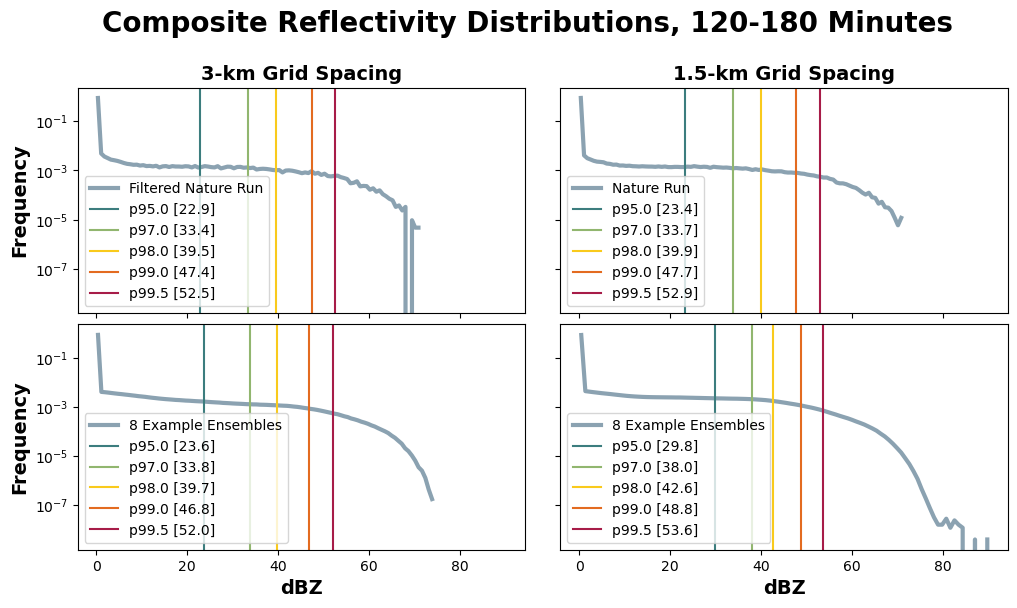

In [60]:
import matplotlib.pyplot as plt
import colormaps as cmaps
def plot_distribution(ax, var, **kwargs):
    hist, bins = np.histogram(var, bins=100)
    bins = (bins[1:]+bins[:-1])/2.0
    ax.semilogy(bins, hist / len(var),**kwargs)


#var = 'UH_2-5km'
#

var = 'cdbz'


exps = ['C15_H15_V4','C15_H12_V4','C15_H12_V4','C15_H09_V4', 'C03_H12_V4','C03_H09_V4', 'C03_H09_V2','C03_H07_V4']

##############################################

fig, axes = plt.subplots(2,2, figsize=(12,6), sharex=True, sharey=True)

colors = cmaps.pride(np.linspace(0.25, 0.8, 5))
line_color = "#6E8B9E"

if var == 'UH_2-5km':
    perc_array = [99.75,99.85, 99.90, 99.95, 99.99] # use 99.90 for UH storm objects

    plt.suptitle(r'$\mathbf{\left| {UH} \right|}$'+' Distributions, 120-180 Minutes', fontsize=20, weight='bold', y=1.01)
    axes[1,0].set_xlabel('m$\mathbf{^2}$ s$\mathbf{^{-2}}$', fontsize=14, weight='bold')
    axes[1,1].set_xlabel('m$\mathbf{^2}$ s$\mathbf{^{-2}}$', fontsize=14, weight='bold')
else:
    perc_array = [95.0, 97.0, 98.0, 99.0, 99.5] # use 98.0 for cdbz storm objects 

    plt.suptitle('Composite Reflectivity Distributions, 120-180 Minutes', fontsize=20, weight='bold', y=1.01)
    axes[1,0].set_xlabel('dBZ', fontsize=14, weight='bold')
    axes[1,1].set_xlabel('dBZ', fontsize=14, weight='bold')


axes[0,0].set_title('3-km Grid Spacing', fontsize=14, weight='bold')
axes[0,1].set_title('1.5-km Grid Spacing', fontsize=14, weight='bold')

plt.subplots_adjust(wspace=0.08, hspace=0.05)

axes[0,0].set_ylabel('Frequency', fontsize=14, weight='bold')
axes[1,0].set_ylabel('Frequency', fontsize=14, weight='bold')

###################################################
######### 3-km experiments 
print('3-km experiments')
with xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars.nc') as ds:

    NRtime = [(pd.to_datetime(t) - dt.datetime(2024, 5, 8, 19, 30)).seconds/60 for t in ds.dates.values[:]]
    tis =[findnearest(NRtime, t) for t in time]
    myvar = abs(ds[var][tis].values.flatten())

    plot_distribution(axes[0,0], myvar, label='Filtered Nature Run', color=line_color, lw=3, alpha=0.8)

    for pi, perc in enumerate(perc_array): # use 99.85 for UH storm objects?
        nrval=np.percentile(myvar, perc)
        axes[0,0].axvline(nrval, color=colors[pi], linestyle='-', label=f'p{perc} [{nrval:.1f}]')
         
axes[0,0].legend()

temp = []
for exp in exps:
    print(exp, end=',')
    with xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc', decode_timedelta=True) as cm1:
        time = [(pd.to_datetime(t) - dt.datetime(2024, 5, 8, 19, 30)).seconds/60 for t in cm1.time.values[-13:]]
        temp.extend(abs(cm1[var][-13:, :-1].values.flatten()))

plot_distribution(axes[1,0], temp, label='8 Example Ensembles', color=line_color, lw=3, alpha=0.8)
for pi, perc in enumerate(perc_array): # use 99.85 for UH storm objects?
    nrval=np.percentile(temp, perc)
    axes[1,0].axvline(nrval, color=colors[pi], linestyle='-', label=f'p{perc} [{nrval:.1f}]')

axes[1,0].legend()   
###################################################

###################################################
######### 1.5-km experiments 
print('1.5-km experiments')

with xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars_fine.nc') as ds:

    NRtime = [(pd.to_datetime(t) - dt.datetime(2024, 5, 8, 19, 30)).seconds/60 for t in ds.dates.values[:]]
    tis =[findnearest(NRtime, t) for t in time]
    myvar = abs(ds[var][tis].values.flatten())

    plot_distribution(axes[0,1], myvar, label='Nature Run', color=line_color, lw=3, alpha=0.8)

    for pi, perc in enumerate(perc_array): # use 99.85 for UH storm objects?
        nrval=np.percentile(myvar, perc)
        axes[0,1].axvline(nrval, color=colors[pi], linestyle='-', label=f'p{perc} [{nrval:.1f}]')
         
axes[0,1].legend()


temp = []
for exp in exps:
    print(exp, end=',')
    with xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}_fine/full_ens_fcst.nc', decode_timedelta=True) as cm1:
        time = [(pd.to_datetime(t) - dt.datetime(2024, 5, 8, 19, 30)).seconds/60 for t in cm1.time.values[-13:]]
        temp.extend(abs(cm1[var][-13:, :-1].values.flatten()))

plot_distribution(axes[1,1], temp, label='8 Example Ensembles', color=line_color, lw=3, alpha=0.8)
for pi, perc in enumerate(perc_array): # use 99.85 for UH storm objects?
    nrval=np.percentile(temp, perc)
    axes[1,1].axvline(nrval, color=colors[pi], linestyle='-', label=f'p{perc} [{nrval:.1f}]')

axes[1,1].legend()   
###################################################



In [ ]:

var = 'cdbz'
perc_array = [95.0, 97.0, 98.0, 99.0, 99.5] # use 99.0 for cdbz storm objects 

# temp = []
# for exp in exps:
#     print(exp, end=',')
#     with xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/full_ens_fcst.nc', decode_timedelta=True) as cm1:
#         time = [(pd.to_datetime(t) - dt.datetime(2024, 5, 8, 19, 30)).seconds/60 for t in cm1.time.values[-13:]]
#         temp.extend(abs(cm1[var][-13:, :-1].values.flatten()))

#plot_distribution(axes[1,0], temp, label='8 Example Ensembles', color=line_color, lw=3, alpha=0.8)
for pi, perc in enumerate(perc_array): # use 99.85 for UH storm objects?
    nrval=np.percentile(temp, perc)
    print(perc, nrval)
    #axes[1,0].axvline(nrval, color=colors[pi], linestyle='-', label=f'p{perc} [{nrval:.1f}]')

95.0 23.90981674194336
97.0 33.813241767883284
98.0 39.76664161682132
99.0 46.82082958221423
99.5 51.97122573852539


In [ ]:

ens2nr = {'UH_2-5km': {50: 29, 100: 62, 150: 103, 200: 160, 300:278, 400: 418}, 
               'cdbz': {30: 20, 35: 27, 40: 35, 45: 42, 50: 48, 55: 54}}

['/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H12_V4_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H18_V6_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H09_V2_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H07_V4_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V4_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V2_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H15_V6_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H12_V4_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H18_V6_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H15_V4_fine',
 '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H09_V4_fine']

# Fractions Skill Score 

In [5]:
from scipy.ndimage import uniform_filter
import netCDF4
import os
import numpy as np
import xarray as xr
import pandas as pd
import glob


def _fraction_2d(mask, winsize):
    area = winsize * winsize
    counts = np.rint(
        uniform_filter(
            mask.astype(np.float64),
            size=(1, winsize, winsize),
            mode='constant',
            cval=0.0,
        ) * area
    )
    return counts / area


def _fraction_ensemble(mask, ne, winsize):
    area = winsize * winsize
    volume = 2 * ne * area
    counts = np.rint(
        uniform_filter(
            mask.astype(np.float64),
            size=(1, 2 * ne, winsize, winsize),
            mode='constant',
            cval=0.0,
        ) * volume
    )
    return np.max(counts / (ne * area), axis=1)


def _fraction_members(mask, winsize):
    area = winsize * winsize
    counts = np.rint(
        uniform_filter(
            mask.astype(np.float64),
            size=(1, 1, winsize, winsize),
            mode='constant',
            cval=0.0,
        ) * area
    )
    return counts / area


def _thresholds(data, pct_values, fixed_values, usepct):
    if usepct == 1:
        values = np.percentile(data, pct_values)
        print('percentiles value array:', values)

    else:
        values = np.asarray(fixed_values, dtype=np.float64)
    return np.repeat(values[None, :], data.shape[0], axis=0)


def _compute_case(fcst, mrms, fcst_thld, mrms_thld, neighsize, ne, dx):
    nt = fcst.shape[0]
    nft = fcst_thld.shape[1]
    nnw = len(neighsize)

    fcst_max = np.max(fcst, axis=(1, 2, 3))
    mrms_max = np.max(mrms, axis=(1, 2))
    fcst_nonneg = np.count_nonzero(fcst >= 0.0, axis=(1, 2, 3)).astype(np.float64)
    mrms_nonneg = np.count_nonzero(mrms >= 0.0, axis=(1, 2)).astype(np.float64)

    efbs   = np.full((nt, nnw, nft), -999.0, dtype=np.float64)
    efbsr  = np.full((nt, nnw, nft), -999.0, dtype=np.float64)
    efss   = np.full((nt, nnw, nft), -999.0, dtype=np.float64)
    fssu   = np.full((nt, nft), -999.0, dtype=np.float64)
    aefss  = np.full((nt, nft), -999.0, dtype=np.float64)
    scales = np.asarray([(ns - 1.0) * dx / 1000.0 for ns in neighsize], dtype=np.float64)
    po     = np.full((nt, nft), 0.0, dtype=np.float64)
    pf     = np.full((nt, nft), 0.0, dtype=np.float64)
    fbs    = np.full((ne, nt, nnw, nft), -999.0, dtype=np.float64)
    fss    = np.full((ne, nt, nnw, nft), -999.0, dtype=np.float64)
    fbsr   = np.full((ne, nt, nnw, nft), -999.0, dtype=np.float64)
    afss   = np.full((ne, nt, nft), -999.0, dtype=np.float64)

    for ts in range(nt):
        fcst_ts  = fcst[ts]
        mrms_ts  = mrms[ts]
        fcst_thr = fcst_thld[ts]
        mrms_thr = mrms_thld[ts]

        fcst_bin = fcst_ts[None, :, :, :] >= fcst_thr[:, None, None, None]
        mrms_bin = mrms_ts[None, :, :] >= mrms_thr[:, None, None]

        po[ts]         = np.count_nonzero(mrms_bin, axis=(1, 2)) / mrms_nonneg[ts]
        pf[ts]         = np.count_nonzero(fcst_bin, axis=(1, 2, 3)) / fcst_nonneg[ts]
        fssu[ts]       = 0.5 + po[ts] / 2.0
        aefss[ts]      = (2.0 * po[ts] * pf[ts]) / (np.power(po[ts], 2) + np.power(pf[ts], 2))
        afss[:, ts, :] = aefss[ts][None, :]

        valid = (fcst_max[ts] >= fcst_thr) | (mrms_max[ts] >= mrms_thr)
        if not np.any(valid):
            continue

        obs_frac = _fraction_2d(mrms_bin, int(neighsize[0]))
        member_frac = _fraction_members(fcst_bin, int(neighsize[0]))
        ens_frac = _fraction_ensemble(fcst_bin, ne, int(neighsize[0]))

        for ii, win in enumerate(neighsize):
            win = int(win)
            obs_frac    = _fraction_2d(mrms_bin, win)
            member_frac = _fraction_members(fcst_bin, win)
            ens_frac    = _fraction_ensemble(fcst_bin, ne, win)

            efbs_vals   = np.mean((ens_frac[valid] - obs_frac[valid]) ** 2, axis=(1, 2))
            efbsr_vals  = np.mean(ens_frac[valid] ** 2 + obs_frac[valid] ** 2, axis=(1, 2))
            efss_vals   = 1.0 - efbs_vals / efbsr_vals

            member_fbs  = np.mean((member_frac[valid] - obs_frac[valid, None, :, :]) ** 2, axis=(2, 3))
            member_fbsr = np.mean(member_frac[valid] ** 2 + obs_frac[valid, None, :, :] ** 2, axis=(2, 3))
            member_fss  = 1.0 - member_fbs / member_fbsr

            efbs[ts, ii, valid]    = efbs_vals
            efbsr[ts, ii, valid]   = efbsr_vals
            efss[ts, ii, valid]    = efss_vals
            fbs[:, ts, ii, valid]  = member_fbs.T
            fbsr[:, ts, ii, valid] = member_fbsr.T
            fss[:, ts, ii, valid]  = member_fss.T

    return {
        'fcst_thld': fcst_thld,
        'mrms_thld': mrms_thld,
        'fcst_max':  fcst_max,
        'mrms_max':  mrms_max,
        'efbs':      efbs,
        'efbsr':     efbsr,
        'efss':      efss,
        'fssu':      fssu,
        'aefss':     aefss,
        'scales':    scales,
        'po':        po,
        'pf':        pf,
        'fbs':       fbs,
        'fss':       fss,
        'fbsr':      fbsr,
        'afss':      afss,
    }


def _write_output(out_file, fcst_time, fcst_hr, fcst_min, results, ne):
    time_units = 'seconds since 1970-01-01 00:00:00'
    nt = len(fcst_time)
    nnw = len(results['scales'])
    nth = results['fcst_thld'].shape[1]

    time_seconds = np.asarray(
        [netCDF4.date2num(t, time_units) for t in fcst_time],
        dtype=np.float64,
    )

    ds = xr.Dataset(
        data_vars={
            'FCST_MAX_VALUE': (('NT',), np.asarray(results['fcst_max'], dtype=np.float32)),
            'MRMS_MAX_VALUE': (('NT',), np.asarray(results['mrms_max'], dtype=np.float32)),
            'TIME'          : (('NT',), time_seconds),
            'HOUR'          : (('NT',), np.asarray(fcst_hr, dtype=np.float32)),
            'MINUTE'        : (('NT',), np.asarray(fcst_min, dtype=np.float32)),
            'SCALES'        : (('NW',), np.asarray(results['scales'], dtype=np.float32)),
            'FCST_THLDS'    : (('NT', 'NTH'), np.asarray(results['fcst_thld'], dtype=np.float32)),
            'MRMS_THLDS'    : (('NT', 'NTH'), np.asarray(results['mrms_thld'], dtype=np.float32)),
            'FSSU'          : (('NT', 'NTH'), np.asarray(results['fssu'], dtype=np.float32)),
            'EFSS'          : (('NT', 'NW', 'NTH'), np.asarray(results['efss'], dtype=np.float32)),
            'EFBS'          : (('NT', 'NW', 'NTH'), np.asarray(results['efbs'], dtype=np.float32)),
            'EFBSR'         : (('NT', 'NW', 'NTH'), np.asarray(results['efbsr'], dtype=np.float32)),
            'AEFSS'         : (('NT', 'NTH'), np.asarray(results['aefss'], dtype=np.float32)),
            'PO'            : (('NT', 'NTH'), np.asarray(results['po'], dtype=np.float32)),
            'PF'            : (('NT', 'NTH'), np.asarray(results['pf'], dtype=np.float32)),
            'FSS'           : (('NE', 'NT', 'NW', 'NTH'), np.asarray(results['fss'], dtype=np.float32)),
            'FBS'           : (('NE', 'NT', 'NW', 'NTH'), np.asarray(results['fbs'], dtype=np.float32)),
            'FBSR'          : (('NE', 'NT', 'NW', 'NTH'), np.asarray(results['fbsr'], dtype=np.float32)),
            'AFSS'          : (('NE', 'NT', 'NTH'), np.asarray(results['afss'], dtype=np.float32)),
        },
        coords={
            'NE'            : np.arange(ne, dtype=np.int32),
            'NT'            : np.arange(nt, dtype=np.int32),
            'NW'            : np.arange(nnw, dtype=np.int32),
            'NTH'           : np.arange(nth, dtype=np.int32),
        },
    )

    ds['TIME'].attrs['unit'] = time_units

    encoding = {
        'TIME'              : {'dtype': 'float64'},
        'FCST_MAX_VALUE'    : {'dtype': 'float32'},
        'MRMS_MAX_VALUE'    : {'dtype': 'float32'},
        'HOUR'              : {'dtype': 'float32'},
        'MINUTE'            : {'dtype': 'float32'},
        'SCALES'            : {'dtype': 'float32'},
        'FCST_THLDS'        : {'dtype': 'float32'},
        'MRMS_THLDS'        : {'dtype': 'float32'},
        'FSSU'              : {'dtype': 'float32'},
        'EFSS'              : {'dtype': 'float32'},
        'EFBS'              : {'dtype': 'float32'},
        'EFBSR'             : {'dtype': 'float32'},
        'AEFSS'             : {'dtype': 'float32'},
        'PO'                : {'dtype': 'float32'},
        'PF'                : {'dtype': 'float32'},
        'FSS'               : {'dtype': 'float32'},
        'FBS'               : {'dtype': 'float32'},
        'FBSR'              : {'dtype': 'float32'},
        'AFSS'              : {'dtype': 'float32'},
    }

    ds.to_netcdf(out_file, mode='w', format='NETCDF4', encoding=encoding)
    ds.close()
    
ens2nr = {'UH_2-5km': {25: 39, 50: 75, 75: 114, 100: 156, 125: 197, 150: 230}, 
               'cdbz': {30: 30, 35: 35, 40: 40, 45: 45, 50: 50, 55: 55}}


In [6]:
###########################################################
################ MAIN CODE STARTS HERE ####################


########ENTER YOUR FILE PATHS HERE##########################

fpaths = sorted(glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_*_fine/'))
#fpaths = sorted(glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_*/FORECAST*/'))
usepct = 1 # if comparing 3km and 1.5 km stuff, always leave on 1

#fpaths = sorted(glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_*/')) 



#####################################################################################################################################
# note: this code takes ~ 1 (4) minute(s) to produce both UH and cdbz files for a 3 (1.5) km ensemble
for indir in fpaths:
  
    fcst_path = os.path.join(indir, 'full_ens_fcst.nc')

    if not os.path.isfile(fcst_path):
        continue


    ### do a check for what grid you're using 
    # actually, update this so that it's set based on dx?
    split = os.path.normpath(indir).split(os.sep)
    if ('fine' in split[-1]) or ('fine' in split[-2]): # the location changes if its a forecast run
        print('using 1.5 km grid')
        nr_full = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars_fine.nc')
        
    else:
        print('using 3 km grid')
        nr_full = xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars.nc')

    nr_time_index = pd.Index(pd.to_datetime(nr_full.dates.values))


    for var in ['uh2to5', 'compdz']:


        if var == 'uh2to5': name = 'UH'
        if var == 'compdz': name = 'cdbz'

        out_file = os.path.join(indir, f'fss_{name}.nc')
        if (os.path.isfile(out_file) == False) and (os.path.isfile(fcst_path) == True):
            print(f'********************************** {var}')
            print('EXPERIMENT ', indir)
            print('VARIABLE ', var)

            fcst_full = xr.open_dataset(fcst_path)
            fcst_time = pd.to_datetime(fcst_full.time.values)
            time_idx = nr_time_index.get_indexer(fcst_time)
            fcst_hr = fcst_time.hour
            fcst_min = fcst_time.minute
            ne = int(fcst_full.sizes['ne'] - 1)
            dx = np.gradient(np.asarray(fcst_full.xh)).mean()

            if var == 'compdz':
                fcst      = np.asarray(fcst_full['cdbz'][:, :-1].values)
                mrms      = np.asarray(nr_full['cdbz'].values[time_idx])
                fcst_prct = np.array([95.0, 97.0, 98.0, 99.0, 99.5], dtype=np.float64)
                mrms_prct = np.array([95.0, 97.0, 98.0, 99.0, 99.5], dtype=np.float64)
                fcst_thds = np.array( list(ens2nr['cdbz'].keys()), dtype=np.float64)
                mrms_thds = np.array( list(ens2nr['cdbz'].values()), dtype=np.float64)

            elif var == 'uh2to5':
                fcst      = np.abs(np.asarray(fcst_full['UH_2-5km'][:, :-1].values))
                mrms      = np.abs(np.asarray(nr_full['UH_2-5km'].values[time_idx]))
                fcst_prct = np.array([99.75,99.85, 99.90, 99.95, 99.99], dtype=np.float64)
                mrms_prct = np.array([99.75,99.85, 99.90, 99.95, 99.99], dtype=np.float64)
                fcst_thds = np.array( list(ens2nr['UH_2-5km'].keys()), dtype=np.float64)
                mrms_thds = np.array( list(ens2nr['UH_2-5km'].values()), dtype=np.float64)
            else:
                print("%s is an unsupported variable, please use 'compdz' or 'uh2to5'" % var)
                fcst_full.close()
                continue

            nt        = fcst.shape[0]
            ne_check  = fcst.shape[1]
            ny        = fcst.shape[2]
            nx        = fcst.shape[3]
            minxy     = min(nx, ny)
            neighsize = []

            for ii in range(1, minxy):
                ns = ii ** 2
                if ns % 2 == 0:
                    ns = ns - 1
                if ns < minxy:
                    neighsize.append(ns)

            
            fcst_thld = _thresholds(fcst, fcst_prct, fcst_thds, usepct)
            mrms_thld = _thresholds(mrms, mrms_prct, mrms_thds, usepct)
            
            print('Computing eFSS')
            results = _compute_case(fcst, mrms, fcst_thld, mrms_thld, neighsize, ne_check, dx)
            _write_output(out_file, fcst_time, fcst_hr, fcst_min, results, ne_check)

            fcst_full.close()
        else:
            print(indir, ' file already made')

nr_full.close()

using 1.5 km grid
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V2_fine/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V2_fine/  file already made
using 1.5 km grid
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V4_fine/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V4_fine/  file already made
using 1.5 km grid
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V2_fine/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V2_fine/  file already made
using 1.5 km grid
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4_fine/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4_fine/  file already made
using 1.5 km grid
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V6_fine/  file already made
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V6_fine/  file already made
using 1.5 km grid
/work/jessica.mcdonald/CM1_LETKF

In [ ]:
nr_percentile_vals = {
  '3km' : {'UH':{99.75: 53, 99.85: 96,  99.90: 152, 99.95: 256, 99.99: 493}, 'cdbz':{95.0: 23, 97.0: 33, 98.0: 40, 99.0: 47, 99.5: 53}}, 
 '1.5km': {'UH':{99.75: 69, 99.85: 116, 99.90: 174, 99.95: 289, 99.99: 640}, 'cdbz':{95.0: 22, 97.0: 34, 98.0: 40, 99.0: 48, 99.5: 53}}}


# Contigency Table Calculation

In [1]:
import skimage.measure as sm
from scipy import stats
import xarray as xr
import datetime as dt
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import glob

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

def get_object_dataframe(smooth_data, raw_data, threshold, plot=False, spacing=3.0):

    Verif_obj = pd.DataFrame(columns=['area', 'Y0', 'X0', 'coords_scaled', 'coords','eccentricity', 'intensity_max', 'intensity_mean', 'intensity_std', 'member'])
    labeled_array, num_features = sm.label(smooth_data >= threshold,connectivity=2,return_num=True)
    OBS = sm.regionprops_table(labeled_array, intensity_image=raw_data,spacing=(spacing, spacing), properties=['area', 'centroid', 'coords_scaled','coords','eccentricity','intensity_max', 'intensity_mean', 'intensity_std' ])
    df = pd.DataFrame(OBS)

    df['Label_Value'] = df.index + 1 # keep original object ID just to be safe
    df = df.rename(columns={'centroid-0':'Y0', 'centroid-1':'X0'})
    ## now drop anything that doesn't have a) eceentricity < 1, b) intensity_max greater than threshold 2, and c) area > 25 m2
    df = df[(df['eccentricity'] < 1.0) & (df['area']>25)]

    if plot:
        labeled_array2 = np.where(labeled_array > 0, 1,np.nan)
        final = np.zeros_like(labeled_array2)
        for val in df.obj_ID.values:
            final[labeled_array==val] = 1
        final[final<1] = np.nan
    
        plt.pcolormesh(xh, yh, final)
        
    return df.reset_index(drop=True)

def _safe_ratio(num, den):
    den = float(den)
    if den == 0.0:
        den = 1e-10
    return float(num) / den

In [2]:
#############


# name = 'UH'
# percentile_threshold = 99.9 

# name = 'cdbz'
# percentile_threshold =  98.0  # run 98 and 99.5


# all fine
exps = sorted([os.path.basename(g) for g in glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_*fine')])

#exps = ['C15_H12_V6_fine']

# all coarse
# exps = sorted([os.path.basename(g) for g in glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_*_*')])
# exps = [e for e in exps if "fine" not in os.path.basename(e)]

#exps = ['C03_H18_V6_fine','C03_H18_V6']

####################################################################################
####################################################################################


### DO NOT CHANGE THESE UNLESS YOU ARE GOING TO RERUN EVERYTHING!!!!!!!!!!!!!!!
nr_percentile_vals = {
  '3km' : {'UH':{99.75: 53, 99.85: 96,  99.90: 152, 99.95: 256, 99.99: 493}, 'cdbz':{95.0: 23, 97.0: 33, 98.0: 40, 99.0: 47, 99.5: 53}}, 
 '1.5km': {'UH':{99.75: 69, 99.85: 116, 99.90: 174, 99.95: 289, 99.99: 640}, 'cdbz':{95.0: 22, 97.0: 34, 98.0: 40, 99.0: 48, 99.5: 53}}}

Distance_Threshold = 40 ### DO NOT CHANGE


for name, percentile_threshold in zip(['UH', 'cdbz','cdbz'], [99.9, 98.0, 99.5]):
    
    if name == 'UH'    : var = 'UH_2-5km'
    elif name == 'cdbz': var = 'cdbz' 

    FIRST_FLAG = True

    for ei, exp in enumerate(exps):
        
        for fcstn in['','FORECAST_20240508_2100']:

            fpath=os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/',exp, fcstn)

            # only run if it hasnt been calculated yet 
            #if (os.path.isfile(f'{fpath}/performance_{name}_p{percentile_threshold}.nc') == False) & (os.path.isfile(f"{fpath}/full_ens_fcst.nc")): 

            fcst_file_exists = os.path.isfile(f"{fpath}/full_ens_fcst.nc")
            perf_file_exists = os.path.isfile(f'{fpath}/performance_{name}_p{percentile_threshold}.nc')
        
            if fcst_file_exists & (perf_file_exists == False):
                
                print('**********************************')
                print(fpath)

                ########################################
                ## read in ensemble
                with xr.open_dataset(f"{fpath}/full_ens_fcst.nc", decode_timedelta=True) as cm1:

                    ensN = cm1.sizes['ne']-1
                    times = [dt.datetime.strptime(str(pd.to_datetime(t)),'%Y-%m-%d %H:%M:%S') for t in cm1.time.values]
                    tidx = findnearest(times, dt.datetime(2024, 5, 8, 21, 30))

                    # make sure you only have the 1 hour verification period so that it doesn't matter what forecast you're on 
                    cm1 = cm1.isel(t=slice(tidx, len(times)+1))
                    times = [dt.datetime.strptime(str(pd.to_datetime(t)),'%Y-%m-%d %H:%M:%S') for t in cm1.time.values]

                    ens_var      = abs(cm1[var][:,:-1].values.copy()) # you can slap an abs on cdbz and be just fine 
                    ens_threshold = np.percentile(ens_var, percentile_threshold)

                # step 1 Values less than threshold reduced to 0
                ens_var[ens_var < ens_threshold ] = 0.0
                # step 2, smooth with gauss filter, stdev=1
                ens_smooth = gaussian_filter(ens_var, 1, axes=(2,3))
                # step 3, normalize using ratio of max filtered and max raw values, unqiue val for EACH unique field
                ens_ratio  = np.nanmax(ens_var, axis=(2,3)) / np.clip(np.nanmax(ens_smooth, axis=(2,3)), .01,100000) # clip so that there are no divide by zero issues (ratio will be zero anyway)
                ens_smooth = ens_smooth * ens_ratio[:,:,np.newaxis, np.newaxis]

                # set the grid spacing based on experiment name
                if 'fine' in exp: spacing = 1.5
                else: spacing = 3.0
            

                #########################################
                ### read in the nature run if this is your first loop to avoid repeating code
                ### OR, redo the verification object code if you're looping over different grid spacings

                if FIRST_FLAG: # this allows the next statement to not fail on the first loop 
                    verif_obj = pd.DataFrame()
                    verif_obj.attrs['GridSpacing'] = -1 

                if FIRST_FLAG | ((FIRST_FLAG == False) & (verif_obj.attrs['GridSpacing'] != spacing)): 

                    if spacing == 1.5:
                        NR_threshold = nr_percentile_vals['1.5km'][name][percentile_threshold]
                        v_path = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars_fine.nc'
                        print('Using 1.5 km nature run for verification')
                    
                    else:
                        NR_threshold = nr_percentile_vals['3km'][name][percentile_threshold]
                        v_path = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars.nc'
                        print('Using 3 km nature run for verification')
                        
                    # get appropriate variable from the nature run, and index to match the ensemble forecast times
                    with xr.open_dataset(v_path) as ds:

                        times_NR = [dt.datetime.strptime(str(pd.to_datetime(t)),'%Y-%m-%d %H:%M:%S') for t in ds.dates.values]
                        NR_tindex = [findnearest(times_NR, t) for t in times]

                        ds = ds.isel(t=NR_tindex) # index to just the fcst times, pull out needed vars
                        times_NR = [dt.datetime.strptime(str(pd.to_datetime(t)),'%Y-%m-%d %H:%M:%S') for t in ds.dates.values]
                        NR_var = abs(ds[var].values.copy())
                        

                    # now process the verification data using the same steps as the ensemble (but without the ensemble dimension)
                    NR_var[NR_var < NR_threshold] = 0.0
                    NR_smooth  = gaussian_filter( NR_var, 1, axes=(1,2))
                    NR_ratio   = np.max(NR_var, axis=(1,2)) / np.max(NR_smooth, axis=(1,2))
                    NR_smooth  = NR_smooth * NR_ratio[:, np.newaxis, np.newaxis]
            
                    # now create the verification objection dataframe
                    for t in range(len(times)):
                        if t == 0: 
                            verif_obj = get_object_dataframe(NR_smooth[t], NR_var[t], NR_threshold, spacing=spacing)
                            verif_obj['time'] = times_NR[t]
                        else: 
                            temp = get_object_dataframe(NR_smooth[t], NR_var[t], NR_threshold, spacing=spacing)
                            temp['time']= times_NR[t]
                            verif_obj = pd.concat([verif_obj,temp])

                    verif_obj.reset_index(drop=True, inplace=True)
                    verif_obj['Object_ID'] = verif_obj.index + 1
                    verif_obj.attrs['GridSpacing'] = spacing 
                    

                    FIRST_FLAG = False

                print('Variable:', name, 'Percentile:', percentile_threshold, 'grid spacing:', spacing)
                print('NR Threshold:', NR_threshold, 'Ensemble Threshold:', ens_threshold)
                    
                
                
                #########################################
                #### now the object identification steps
                
                ### prepare for xarray file creation 
                hits_grid = np.zeros([len(times), ensN])
                miss_grid = np.zeros([len(times), ensN])      
                fa_grid   = np.zeros([len(times), ensN])
                pod_grid  = np.zeros([len(times)])
                far_grid  = np.zeros([len(times)])
                sr_grid   = np.zeros([len(times)])
                
                #### now loop over all the times 
                save_flag=True
                for t in range(len(times)):
                
                    # pull out the appropriate time to verify against
                    verif = verif_obj[verif_obj.time == times[t]].copy()
                    verif.reset_index(drop=True, inplace=True)
                    
                    # contingency variables for a single time step
                    contingency = pd.DataFrame(data = np.zeros((ensN, 3)), index=np.arange(1,  ensN+1),columns = ['hits', 'misses', 'false_alarms'])
            
                    # loop over all members
                    for m in np.arange(0, ensN):
                    
                        fcst = get_object_dataframe(ens_smooth[t,m], ens_var[t,m], ens_threshold, spacing=spacing)
                        if len(fcst) > 0:  # you have objects! 
            
                            # prep forecast file
                            fcst.reset_index(drop=True, inplace=True)
                            fcst['member'] = m+1
                            fcst['closest'] = 0
                            fcst['v_distance'] = np.nan
                            fcst['v_max'] = np.nan
                            fcst['v_area'] = np.nan
                            fcst['v_eccen'] = np.nan
                            fcst['time'] = times[t]
        
                            # first find distance to each object
                            for obj in verif.index:
                                obj_i = verif['Object_ID'][obj]
                                fcst[f'dist_{obj_i}'] = np.hypot(fcst.Y0.values - verif.Y0.values[obj],  fcst.X0.values - verif.X0.values[obj])
                    
        
                            # make a matrix of all distances, where row =forecast object and column = verification object
                            allvs = [f'dist_{v}' for v in verif.Object_ID.values]
                            matrix = []
                            for obj in fcst.index:
                                matrix.append(list(fcst.loc[obj][allvs].values))
                            
                            matrix = np.array(matrix)
                            solver = np.zeros_like(matrix)
                            
                            # iteratively go over matrix starting with smallest size, dropping each forecast object and verif object that is globally matched
                            for i in range(len(verif)):
                                global_min = np.min(matrix)
                                
                                f, v = np.where(matrix == global_min)
        
                                if global_min < Distance_Threshold:
                                
                                    solver[f,v] = 1
                                    matrix[f,:] = 1000
                                    matrix[:,v] = 1000
                            
                            for f in range(len(fcst)):
                                if np.any(solver[f]==1):
                                    fcst.at[f, 'closest'] = verif.Object_ID.values[np.argmax(solver[f])]
                                    fcst.at[f, 'v_distance'] = fcst.at[f, f'dist_{fcst.at[f, "closest"]}']
                                    temp = verif[verif.Object_ID == fcst.at[f, "closest"]]
                                    fcst.loc[f, 'v_max']   = temp.intensity_max.values[0]
                                    fcst.loc[f, 'v_mean']   = temp.intensity_mean.values[0]
                                    fcst.loc[f, 'v_std']   = temp.intensity_std.values[0]
                                    fcst.loc[f, 'v_area']  = temp.area.values[0]
                                    fcst.loc[f, 'v_eccen'] = temp.eccentricity.values[0]
        
                            fcst.drop(columns=[f'dist_{obj_i}' for obj_i in  verif['Object_ID']], inplace=True)
                            
                            hits = solver.sum()
                            false_alarms = np.clip(len(fcst) - hits, 0, 100000000)
                            misses = np.clip(len(verif) - hits, 0, 10000000)
        
                            # now save all objects to master file
                            if save_flag: all_mem = fcst.copy(); save_flag=False
                            else: all_mem = pd.concat([all_mem, fcst])
        
                        # you have no objects     
                        else:
                            hits = 0
                            false_alarms = 0
                            misses = len(verif)
                            
                        contingency.loc[m+1, 'hits'] = hits
                        contingency.loc[m+1, 'false_alarms'] = false_alarms
                        contingency.loc[m+1, 'misses'] = misses
                    
                    
                    # now sum everything for ensemble PD, etc for a single time step 
                    a = contingency['hits'].sum()
                    b = contingency['false_alarms'].sum()
                    c = contingency['misses'].sum()
                    
                    POD = _safe_ratio(a, a + c)
                    FAR = _safe_ratio(b, a + b)
                    Success_Ratio = 1 - FAR
                    
                    hits_grid[t, :] = contingency['hits'].values
                    miss_grid[t, :] = contingency['misses'].values     
                    fa_grid[t, :]   = contingency['false_alarms'].values  
                    pod_grid[t]     = POD
                    far_grid[t]     = FAR
                    sr_grid[t]      = Success_Ratio
                
                
                all_mem.reset_index(drop=True, inplace=True)
                all_mem.to_csv(f'{fpath}/objects_{name}_p{percentile_threshold}.csv', index = None)
                
                coords = {
                        't'    : np.arange(0, len(times)),
                        'ne'   : np.arange(0, ensN),}
                
                data_vars = { 
                    'time'                     : (['t'],times),
                    'hits'                     : (['t','ne'], hits_grid),
                    'misses'                   : (['t','ne'], miss_grid),
                    'false_alarms'             : (['t','ne'], fa_grid),
                    'POD_t'                    : (['t'], pod_grid),
                    'FAR_t'                    : (['t'], far_grid),
                    'S_RATIO_t'                : (['t'], sr_grid),}
                
                myds = xr.Dataset(data_vars, coords)
                myds.attrs['Ens_threshold'] = np.round(ens_threshold, 1)
                myds.attrs['NR_threshold']  = NR_threshold
    
                myds.to_netcdf(f'{fpath}/performance_{name}_p{percentile_threshold}.nc', format='NETCDF4')
                verif_obj.to_csv(f'{fpath}/verification_{name}_p{percentile_threshold}.csv', index=None)
        
                
            else:
                print(f'{fpath} already has file done')


/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V2_fine/ already has file done
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V2_fine/FORECAST_20240508_2100 already has file done
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V4_fine/ already has file done
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V4_fine/FORECAST_20240508_2100 already has file done
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V6_fine/ already has file done
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H07_V6_fine/FORECAST_20240508_2100 already has file done
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V2_fine/ already has file done
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V2_fine/FORECAST_20240508_2100 already has file done
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4_fine/ already has file done
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C03_H09_V4_fine/FORECAST_20240508_2100 already has file done


In [4]:
t = dt.datetime(2024, 5, 8, 21,30)

t.strftime('%Y,%m,%d,%H,%M,%S')

'2024,05,08,21,30,00'

In [ ]:
# claude's version of the contigency table stuff, I don't trust it tho
# Rewritten object-based contingency-table workflow for readability and safer behavior.
# This cell is self-contained and can be run independently of earlier contingency-table cells.

import os
import glob
import datetime as dt
import numpy as np
import pandas as pd
import xarray as xr
import skimage.measure as sm
from scipy.ndimage import gaussian_filter


def _findnearest(array, value):
    array = np.asarray(array)
    return int(np.abs(array - value).argmin())


def _to_datetimes(values):
    return [dt.datetime.strptime(str(pd.to_datetime(v)), "%Y-%m-%d %H:%M:%S") for v in values]


def _object_dataframe(smooth_data, raw_data, threshold, min_area=25.0, spacing_km=3.0):
    labeled_array, _ = sm.label(smooth_data >= threshold, connectivity=2, return_num=True)
    props = sm.regionprops_table(
        labeled_array,
        intensity_image=raw_data,
        spacing=(spacing_km, spacing_km),
        properties=[
            "area",
            "centroid",
            "coords_scaled",
            "coords",
            "eccentricity",
            "intensity_max",
            "intensity_mean",
            "intensity_std",
        ],
    )
    df = pd.DataFrame(props)
    if df.empty:
        return df

    df = df.rename(columns={"centroid-0": "Y0", "centroid-1": "X0"})
    df["Label_Value"] = np.arange(1, len(df) + 1, dtype=np.int64)
    df = df[(df["eccentricity"] < 1.0) & (df["area"] > min_area)].copy()
    df.reset_index(drop=True, inplace=True)
    return df


def _match_objects(fcst, verif, distance_threshold_km):
    fcst = fcst.copy()
    n_fcst = len(fcst)
    n_ver = len(verif)

    fcst["closest"] = 0
    fcst["v_distance"] = np.nan
    fcst["v_max"] = np.nan
    fcst["v_mean"] = np.nan
    fcst["v_std"] = np.nan
    fcst["v_area"] = np.nan
    fcst["v_eccen"] = np.nan

    if n_fcst == 0 and n_ver == 0:
        return fcst, 0, 0, 0
    if n_fcst == 0:
        return fcst, 0, 0, int(n_ver)
    if n_ver == 0:
        return fcst, 0, int(n_fcst), 0

    fcst_xy = fcst[["Y0", "X0"]].to_numpy(dtype=np.float64)
    ver_xy = verif[["Y0", "X0"]].to_numpy(dtype=np.float64)

    dist = np.hypot(
        fcst_xy[:, None, 0] - ver_xy[None, :, 0],
        fcst_xy[:, None, 1] - ver_xy[None, :, 1],
    )

    # Greedy one-to-one matching from globally smallest distance upward.
    used_fcst = np.zeros(n_fcst, dtype=bool)
    used_ver = np.zeros(n_ver, dtype=bool)
    pairs = []

    while True:
        masked = dist.copy()
        masked[used_fcst, :] = np.inf
        masked[:, used_ver] = np.inf
        minval = np.min(masked)
        if not np.isfinite(minval) or minval >= distance_threshold_km:
            break
        f_idx, v_idx = np.unravel_index(np.argmin(masked), masked.shape)
        used_fcst[f_idx] = True
        used_ver[v_idx] = True
        pairs.append((f_idx, v_idx, minval))

    for f_idx, v_idx, dval in pairs:
        ver_row = verif.iloc[v_idx]
        fcst.loc[f_idx, "closest"] = int(ver_row["Object_ID"])
        fcst.loc[f_idx, "v_distance"] = float(dval)
        fcst.loc[f_idx, "v_max"] = float(ver_row["intensity_max"])
        fcst.loc[f_idx, "v_mean"] = float(ver_row["intensity_mean"])
        fcst.loc[f_idx, "v_std"] = float(ver_row["intensity_std"])
        fcst.loc[f_idx, "v_area"] = float(ver_row["area"])
        fcst.loc[f_idx, "v_eccen"] = float(ver_row["eccentricity"])

    hits = int(len(pairs))
    false_alarms = int(n_fcst - hits)
    misses = int(n_ver - hits)
    return fcst, hits, false_alarms, misses


def _safe_ratio(num, den):
    den = float(den)
    if den == 0.0:
        return np.nan
    return float(num) / den


def _prepare_verification(ds_in, times, var, nr_threshold):
    if var == "UH_2-5km":
        nr_var = np.abs(np.asarray(ds_in[var].values.copy()))
    elif var == "dbz":
        nr_var = np.asarray(ds_in[var].values.copy())
    else:
        nr_var = np.asarray(ds_in[var].values.copy())

    nr_var[nr_var < nr_threshold] = 0.0
    nr_smooth = gaussian_filter(nr_var, 1, axes=(1, 2))
    nr_ratio = np.nanmax(nr_var, axis=(1, 2)) / np.clip(np.nanmax(nr_smooth, axis=(1, 2)), 0.01, 1.0e6)
    nr_smooth = nr_smooth * nr_ratio[:, None, None]

    verif_obj_all = []
    for t in range(len(times)):
        vdf = _object_dataframe(nr_smooth[t], nr_var[t], nr_threshold)
        if not vdf.empty:
            vdf["time"] = times[t]
            verif_obj_all.append(vdf)

    if verif_obj_all:
        verif_obj = pd.concat(verif_obj_all, ignore_index=True)
        verif_obj["Object_ID"] = np.arange(1, len(verif_obj) + 1, dtype=np.int64)
    else:
        verif_obj = pd.DataFrame(
            columns=[
                "area", "Y0", "X0", "coords_scaled", "coords", "eccentricity",
                "intensity_max", "intensity_mean", "intensity_std", "Label_Value",
                "time", "Object_ID",
            ]
        )
    return verif_obj


def run_contingency_table_rewrite(
    exps,
    fcst_subdirs=("", "FORECAST_20240508_2100"),
    base_dir="/work/jessica.mcdonald/CM1_LETKF_2025/experiments",
    var="cdbz",
    name="compdbz",
    ens_threshold=40,
    distance_threshold_km=40,
    write_netcdf=False,
    netcdf_suffix="",
):
    ens2nr = {
        "UH_2-5km": {50: 29, 100: 62, 150: 103, 200: 160, 300: 278, 400: 418},
        "cdbz": {30: 20, 35: 27, 40: 35, 45: 42, 50: 48, 55: 54},
    }

    for fcstn in fcst_subdirs:
        verif_cache = None
        for exp in exps:
            fpath = os.path.join(base_dir, exp, fcstn)
            fcst_file = os.path.join(fpath, "full_ens_fcst.nc")
            if not os.path.isfile(fcst_file):
                print(f"{fpath} already has file done" if os.path.isdir(fpath) else f"Skipping missing path: {fpath}")
                continue

            add = "" if distance_threshold_km == 40 else f"_{distance_threshold_km}km"
            print(f"Processing: {fpath}")

            with xr.open_dataset(fcst_file, decode_timedelta=True) as cm1:
                times = _to_datetimes(cm1.time.values)
                ensN = int(cm1.sizes["ne"] - 1)

                if var == "UH_2-5km":
                    nr_threshold = ens2nr[var][ens_threshold]
                    ens_var = np.abs(cm1[var][:, :-1].values.copy())
                elif var == "dbz":
                    nr_threshold = ens_threshold
                    zi = _findnearest(cm1.z.values, 2)
                    ens_var = cm1[var][:, :-1, zi].values.copy()
                else:
                    nr_threshold = ens_threshold
                    ens_var = cm1[var][:, :-1].values.copy()

            if verif_cache is None:
                verif_file = os.path.join(base_dir, "Processed_VerificationVars_fine.nc")
                with xr.open_dataset(verif_file) as ds_full:
                    ds_work = ds_full.rename({"UH2-5km": "UH_2-5km"})
                    times_nr_full = _to_datetimes(ds_work.dates.values)
                    nr_tindex = [_findnearest(times_nr_full, t) for t in times]
                    ds_slice = ds_work.isel(t=nr_tindex).load()
                    times_nr = _to_datetimes(ds_slice.dates.values)
                verif_obj = _prepare_verification(ds_slice, times_nr, var, nr_threshold)
                verif_cache = (verif_obj, times_nr)
            else:
                verif_obj, times_nr = verif_cache

            verif_out = os.path.join(fpath, f"verification_{name}_{ens_threshold}{add}.csv")
            verif_obj.to_csv(verif_out, index=False)

            ens_var[ens_var < ens_threshold] = 0.0
            ens_smooth = gaussian_filter(ens_var, 1, axes=(2, 3))
            ens_ratio = np.nanmax(ens_var, axis=(2, 3)) / np.clip(np.nanmax(ens_smooth, axis=(2, 3)), 0.01, 1.0e6)
            ens_smooth = ens_smooth * ens_ratio[:, :, None, None]

            ntime = len(times)
            hits_grid = np.zeros((ntime, ensN), dtype=np.float64)
            miss_grid = np.zeros((ntime, ensN), dtype=np.float64)
            fa_grid = np.zeros((ntime, ensN), dtype=np.float64)
            pod_grid = np.full(ntime, np.nan, dtype=np.float64)
            far_grid = np.full(ntime, np.nan, dtype=np.float64)
            sr_grid = np.full(ntime, np.nan, dtype=np.float64)

            all_members = []
            for t in range(ntime):
                verif_t = verif_obj[verif_obj["time"] == times[t]].copy()
                verif_t.reset_index(drop=True, inplace=True)

                contingency = np.zeros((ensN, 3), dtype=np.float64)  # hits, misses, false alarms
                for m in range(ensN):
                    fcst_t = _object_dataframe(ens_smooth[t, m], ens_var[t, m], ens_threshold)
                    fcst_t["member"] = m + 1
                    fcst_t["time"] = times[t]

                    matched, hits, false_alarms, misses = _match_objects(
                        fcst_t, verif_t, distance_threshold_km
                    )

                    contingency[m, 0] = hits
                    contingency[m, 1] = misses
                    contingency[m, 2] = false_alarms

                    if not matched.empty:
                        all_members.append(matched)

                a = contingency[:, 0].sum()
                b = contingency[:, 2].sum()
                c = contingency[:, 1].sum()

                pod_grid[t] = _safe_ratio(a, a + c)
                far_grid[t] = _safe_ratio(b, a + b)
                sr_grid[t] = np.nan if np.isnan(far_grid[t]) else (1.0 - far_grid[t])

                hits_grid[t, :] = contingency[:, 0]
                miss_grid[t, :] = contingency[:, 1]
                fa_grid[t, :] = contingency[:, 2]

            if all_members:
                all_mem = pd.concat(all_members, ignore_index=True)
            else:
                all_mem = pd.DataFrame(
                    columns=[
                        "area", "Y0", "X0", "coords_scaled", "coords", "eccentricity",
                        "intensity_max", "intensity_mean", "intensity_std", "Label_Value",
                        "member", "time", "closest", "v_distance", "v_max", "v_mean",
                        "v_std", "v_area", "v_eccen",
                    ]
                )

            obj_out = os.path.join(fpath, f"objects_{name}_{ens_threshold}{add}.csv")
            all_mem.to_csv(obj_out, index=False)

            if write_netcdf:
                coords = {"t": np.arange(ntime), "ne": np.arange(ensN)}
                data_vars = {
                    "time": (["t"], times),
                    "hits": (["t", "ne"], hits_grid),
                    "misses": (["t", "ne"], miss_grid),
                    "false_alarms": (["t", "ne"], fa_grid),
                    "POD_t": (["t"], pod_grid),
                    "FAR_t": (["t"], far_grid),
                    "S_RATIO_t": (["t"], sr_grid),
                }
                myds = xr.Dataset(data_vars=data_vars, coords=coords)
                myds.attrs[f"Ens{ens_threshold}_Equivalent"] = nr_threshold
                perf_file = os.path.join(fpath, f"performance_{name}_{ens_threshold}{add}{netcdf_suffix}.nc")
                myds.to_netcdf(perf_file, format="NETCDF4")
                myds.close()


########## Example run ##########
Distance_Threshold = 40  # km
var = "cdbz"            # "cdbz" or "UH_2-5km"
name = "compdbz"
ens_threshold = 40

# exps can be a long list; keep this short while testing.
exps = ["C15_H18_V6_fine"]

run_contingency_table_rewrite(
    exps=exps,
    fcst_subdirs=("", "FORECAST_20240508_2100"),
    var=var,
    name=name,
    ens_threshold=ens_threshold,
    distance_threshold_km=Distance_Threshold,
    write_netcdf=False,
    netcdf_suffix="",
)

# Adding in Adjusted WTG Values 

In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import glob
import scipy

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

### add in adjusted WTG to balance stats

exps = sorted([os.path.basename(g) for g in glob.glob('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C*_*_fine')])


##############################
fpath = f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/'
control = xr.open_dataset(f'{fpath}Control_fine/balance.nc') #! make sure you have the right Control file!
ti     = findnearest(control.time, 30)
slope, _,_,_,_= scipy.stats.linregress(control['wres'][ti:,:].values.ravel(), control['qr'][ti:,:].values.ravel())
control_rain = control['qr'].values
control.close()


for i,exp in enumerate(exps): 

    if os.path.isfile(f'{fpath}{exp}/balance.nc'):

        wtg = xr.open_dataset(f'{fpath}{exp}/balance.nc')
        i0=findnearest(wtg.time.values, 30) # this will be zero if you used a "pre cooked" set up

        if 'wres_adjusted' not in list(wtg.variables): 
            print(exp)
            i1=findnearest(wtg.time.values, 120)+1
            wres = wtg['wres'].values[i0:]
            rain = wtg['qr'].values[i0:]
            time = wtg.time.values[i0:]
            
            wtg_adjusted = (wres- (1/slope)*(rain - control_rain[ti:ti+len(rain)]))
            
            # if you didn't use a control run, this will fix it 
            if len(wtg_adjusted) < len(wtg['wres']):
                adj = np.zeros((len(wtg['wres']) - len(wtg_adjusted), 36)) *np.nan
                wtg_adjusted = np.concatenate([adj, wtg_adjusted], axis=0)

            wtg['wres_adjusted'] = (wtg.wres.dims, wtg_adjusted)
            temp = wtg['wres_adjusted'].copy()

            wtg.close()
            del wtg
            temp.to_netcdf(f'{fpath}{exp}/balance.nc', format='NETCDF4', mode='a')
    

C03_H18_V4_fine
